# Resume the principal models to 300 / 200 / 300 epochs

This notebook **continues** the completed long runs rather than training new
models from scratch:

| model | completed source run | target total | additional epochs |
|---|---:|---:|---:|
| U-TV | 200 | 300 | 100 |
| U-TGV | 100 | 200 | 100 |
| U-Tikhonov T16/CG32 | 200 | 300 | 100 |

The continuation is methodologically a single optimisation trajectory because
it restores both the network parameters and the complete AdamW state
(including moment estimates and optimiser step counts). It also preserves:

- the original 500/50 SeaTurtle split and preprocessing;
- stochastic training noise with the unchanged distribution;
- deterministic validation at $\sigma=0.1$ with seed 10,000;
- architecture, solver depth, learning rate, weight decay and gradient clipping;
- the complete history and the best validation-PSNR checkpoint over all epochs.

The completed source directories are read-only. Continuation checkpoints are
written to new directories, so the 20-epoch and 200/100/200 experiments remain
available.

## Methodological caveat

The original checkpoints saved model state, optimiser state, arguments and
history, but not random-number-generator states. Consequently, the first
continued epoch cannot reproduce the exact random stream that a hypothetical
uninterrupted run would have used. This does not change the dataset, noise
distribution, optimiser or objective: it begins a new, deterministic and
documented realisation of the deliberately stochastic training augmentation.
Every checkpoint produced by this notebook additionally saves Python, NumPy,
PyTorch and DataLoader-generator RNG states, so later interruptions can resume
exactly at an epoch boundary.

The 300/200/300 budgets are fixed here before the final DIV2K benchmark.

In [1]:
from __future__ import annotations

import json
import os
import platform
import random
import shutil
import sys
import time
from argparse import Namespace
from collections import OrderedDict
from pathlib import Path


def locate_project_root() -> Path:
    # Find cleaned_pipeline regardless of where Jupyter was launched.
    cwd = Path.cwd().resolve()
    candidates = []
    for base in (cwd, *cwd.parents):
        candidates.extend((base, base / "cleaned_pipeline"))
    for candidate in candidates:
        if (candidate / "src").is_dir() and (candidate / "scripts").is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find cleaned_pipeline. Start Jupyter from Thesis/Python, "
        "cleaned_pipeline, or cleaned_pipeline/notebooks."
    )


PROJECT_ROOT = locate_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


Project root: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

from src.data.denoising_dataset import FixedNoiseDataset
from src.data.seaturtle_dataset import SeaTurtleDenoisingDataset
from src.evaluation.benchmark import load_checkpoint, load_project_model
from src.evaluation.denoising_eval import (
    evaluate_denoising_model,
    summarize_results,
    unpack_model_output,
)
from src.training.denoising import (
    apply_common_defaults,
    describe_device,
    get_device,
    seed_everything,
    synchronize_device,
)

device = get_device()
print("PyTorch:", torch.__version__)
print("Device:", device)


PyTorch: 2.12.0
Device: mps


## Configuration
This cell declares source and target epochs, protected input/output directories, run switches, and the independent continuation seed.

`target_epoch` is a **total** epoch count, not the number of additional
epochs. The output names explicitly record the source and target budgets.

In [3]:
CONTINUATION_SEED = 1_000_042

RUN_U_TV = True
RUN_U_TGV = True
RUN_U_TIKHONOV = True

SPECS = OrderedDict([
    ("U-TV", {
        "model_name": "u_tv",
        "source_epoch": 200,
        "target_epoch": 300,
        "source_dir": PROJECT_ROOT / "checkpoints" / "u_tv_e200_from_scratch",
        "output_dir": PROJECT_ROOT / "checkpoints" / "u_tv_e300_resumed_from_e200",
        "run": RUN_U_TV,
        "color": "#4C78A8",
    }),
    ("U-TGV", {
        "model_name": "u_tgv",
        "source_epoch": 100,
        "target_epoch": 200,
        "source_dir": PROJECT_ROOT / "checkpoints" / "u_tgv_e100_from_scratch",
        "output_dir": PROJECT_ROOT / "checkpoints" / "u_tgv_e200_resumed_from_e100",
        "run": RUN_U_TGV,
        "color": "#F58518",
    }),
    ("U-Tikhonov T16/CG32", {
        "model_name": "u_tikhonov",
        "source_epoch": 200,
        "target_epoch": 300,
        "source_dir": PROJECT_ROOT / "checkpoints" / "u_tikhonov_bounded_x16_cg32_e200_from_scratch",
        "output_dir": PROJECT_ROOT / "checkpoints" / "u_tikhonov_bounded_x16_cg32_e300_resumed_from_e200",
        "run": RUN_U_TIKHONOV,
        "color": "#7A5195",
    }),
])

for spec in SPECS.values():
    spec["source_latest"] = spec["source_dir"] / f"{spec['model_name']}_latest.pth"
    spec["source_best"] = spec["source_dir"] / f"{spec['model_name']}_best.pth"
    spec["output_latest"] = spec["output_dir"] / f"{spec['model_name']}_latest.pth"
    spec["output_best"] = spec["output_dir"] / f"{spec['model_name']}_best.pth"

configuration = pd.DataFrame([
    {
        "method": method,
        "source_epoch": spec["source_epoch"],
        "target_epoch": spec["target_epoch"],
        "additional_epochs": spec["target_epoch"] - spec["source_epoch"],
        "source_latest": str(spec["source_latest"]),
        "source_best": str(spec["source_best"]),
        "output_directory": str(spec["output_dir"]),
        "enabled": spec["run"],
    }
    for method, spec in SPECS.items()
])
display(configuration)


,method,source_epoch,target_epoch,additional_epochs,source_latest,source_best,output_directory,enabled
0,U-TV,200,300,100,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...,True
1,U-TGV,100,200,100,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...,True
2,U-Tikhonov T16/CG32,200,300,100,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...,True


## Source-checkpoint and protocol audit

This cell fails before training if a source is missing, if the final epoch is
not the expected 200/100/200, if AdamW state is absent, or if the completed
runs do not share the controlled protocol. The checkpoint arguments remain the authority for model construction.


In [4]:
SHARED_LOCKED_FIELDS = (
    "data_root", "image_size", "max_images", "val_images",
    "sigma_min", "sigma_max", "val_sigma", "val_noise_seed",
    "base_channels", "depth", "batch_size", "lr", "weight_decay",
    "grad_clip", "num_workers", "seed", "clamp_for_metrics",
)

source_checkpoints = {}
audit_rows = []
shared_reference = None

for method, spec in SPECS.items():
    for key in ("source_latest", "source_best"):
        if not spec[key].is_file():
            raise FileNotFoundError(f"Missing {key} for {method}: {spec[key]}")

    latest = load_checkpoint(spec["source_latest"], "cpu")
    best = load_checkpoint(spec["source_best"], "cpu")
    source_checkpoints[method] = latest

    if int(latest["epoch"]) != spec["source_epoch"]:
        raise RuntimeError(
            f"{method}: expected latest epoch {spec['source_epoch']}, "
            f"found {latest['epoch']}."
        )
    if latest.get("model_name") != spec["model_name"]:
        raise RuntimeError(f"{method}: model_name mismatch in latest checkpoint.")
    optimizer_state = latest.get("optimizer_state_dict")
    if not optimizer_state or not optimizer_state.get("state"):
        raise RuntimeError(f"{method}: checkpoint has no populated optimiser state.")

    history = pd.DataFrame(latest.get("history", []))
    if history.empty or int(history["epoch"].iloc[-1]) != spec["source_epoch"]:
        raise RuntimeError(f"{method}: latest checkpoint history is incomplete.")
    if history["epoch"].duplicated().any():
        raise RuntimeError(f"{method}: duplicate epochs in source history.")

    args = latest["args"]
    current_shared = {field: args.get(field) for field in SHARED_LOCKED_FIELDS}
    if shared_reference is None:
        shared_reference = current_shared
    elif current_shared != shared_reference:
        differences = {
            field: (shared_reference[field], current_shared[field])
            for field in SHARED_LOCKED_FIELDS
            if shared_reference[field] != current_shared[field]
        }
        raise RuntimeError(f"Shared-protocol mismatch for {method}: {differences}")

    best_psnr_from_history = float(history["val_psnr"].max())
    best_epoch_from_history = int(history.loc[history["val_psnr"].idxmax(), "epoch"])
    best_psnr_from_file = float(best["val_metrics"]["recon_psnr"])
    if not np.isclose(best_psnr_from_file, best_psnr_from_history, atol=1e-10):
        raise RuntimeError(f"{method}: best checkpoint does not match latest history.")

    solver_iterations = args.get("cg_iters", args.get("num_pdhg_iters"))
    audit_rows.append({
        "method": method,
        "latest_epoch": int(latest["epoch"]),
        "historical_best_epoch": best_epoch_from_history,
        "historical_best_val_psnr": best_psnr_from_history,
        "optimizer_state_entries": len(optimizer_state["state"]),
        "learning_rate": float(args["lr"]),
        "weight_decay": float(args["weight_decay"]),
        "solver_iterations": int(solver_iterations),
        "training_noise": f"U({args['sigma_min']}, {args['sigma_max']})",
        "validation_sigma": float(args["val_sigma"]),
        "validation_seed": int(args["val_noise_seed"]),
    })

source_audit = pd.DataFrame(audit_rows)
display(source_audit)

assert shared_reference["image_size"] == 256
assert shared_reference["max_images"] == 550
assert shared_reference["val_images"] == 50
assert shared_reference["val_sigma"] == 0.1
assert shared_reference["val_noise_seed"] == 10_000
assert shared_reference["base_channels"] == 32
assert shared_reference["depth"] == 3
assert shared_reference["batch_size"] == 1
assert shared_reference["lr"] == 1e-4
assert shared_reference["weight_decay"] == 1e-5
assert shared_reference["grad_clip"] == 1.0
assert shared_reference["seed"] == 42
assert Path(shared_reference["data_root"]).expanduser().is_dir()

print("Checkpoint and shared-protocol audit passed.")


,method,latest_epoch,historical_best_epoch,historical_best_val_psnr,optimizer_state_entries,learning_rate,weight_decay,solver_iterations,training_noise,validation_sigma,validation_seed
0,U-TV,200,197,31.953274,36,0.0001,0.00001,64,"U(0.0, 0.2)",0.1,10000
1,U-TGV,100,100,31.640771,36,0.0001,0.00001,64,"U(0.0, 0.2)",0.1,10000
2,U-Tikhonov T16/CG32,200,185,32.124890,36,0.0001,0.00001,32,"U(0.0, 0.2)",0.1,10000


Checkpoint and shared-protocol audit passed.


## Continuation loader and RNG handling

This cell reconstructs the original dataset split while managing DataLoader, Python, NumPy, PyTorch, and optimiser states for reproducible checkpoint continuation.

The dataset-selection and train/validation split generators keep the original
seed 42. Only the new stochastic augmentation/shuffle stream uses
`CONTINUATION_SEED`. Validation remains locally generated and bitwise fixed,
so validation PSNR is directly comparable across all old and new epochs.


In [5]:
def seed_worker(worker_id):
    del worker_id
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def build_continuation_loaders(args, *, continuation_seed):
    dataset = SeaTurtleDenoisingDataset(
        root_dir=args.data_root,
        image_size=args.image_size,
        sigma_min=args.sigma_min,
        sigma_max=args.sigma_max,
        max_images=args.max_images,
        seed=args.seed,
    )
    train_size = len(dataset) - args.val_images
    train_subset, val_subset = random_split(
        dataset,
        (train_size, args.val_images),
        generator=torch.Generator().manual_seed(args.seed),
    )
    val_dataset = FixedNoiseDataset(
        val_subset,
        sigma=args.val_sigma,
        seed=args.val_noise_seed,
    )

    loader_generator = torch.Generator().manual_seed(continuation_seed)
    loader_kwargs = {
        "batch_size": args.batch_size,
        "num_workers": args.num_workers,
        "worker_init_fn": seed_worker if args.num_workers > 0 else None,
        "persistent_workers": args.num_workers > 0,
    }
    train_loader = DataLoader(
        train_subset,
        shuffle=True,
        generator=loader_generator,
        **loader_kwargs,
    )
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
    return train_loader, val_loader, loader_generator


def capture_rng_state(loader_generator):
    state = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch_cpu": torch.get_rng_state(),
        "loader_generator": loader_generator.get_state(),
    }
    if torch.cuda.is_available():
        state["torch_cuda_all"] = torch.cuda.get_rng_state_all()
    if hasattr(torch, "mps") and hasattr(torch.mps, "get_rng_state"):
        try:
            state["torch_mps"] = torch.mps.get_rng_state()
        except RuntimeError:
            pass
    return state


def restore_rng_state(state, loader_generator):
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch_cpu"])
    loader_generator.set_state(state["loader_generator"])
    if "torch_cuda_all" in state and torch.cuda.is_available():
        torch.cuda.set_rng_state_all(state["torch_cuda_all"])
    if "torch_mps" in state and hasattr(torch, "mps") and hasattr(torch.mps, "set_rng_state"):
        try:
            torch.mps.set_rng_state(state["torch_mps"])
        except RuntimeError:
            pass


def move_optimizer_state(optimizer, resolved_device):
    for state in optimizer.state.values():
        for key, value in state.items():
            if torch.is_tensor(value):
                state[key] = value.to(resolved_device)


def optimizer_step_range(optimizer):
    steps = []
    for state in optimizer.state.values():
        if "step" not in state:
            continue
        value = state["step"]
        steps.append(float(value.item() if torch.is_tensor(value) else value))
    return (min(steps), max(steps)) if steps else (np.nan, np.nan)


def plain_args(args):
    return {
        key: str(value) if isinstance(value, (Path, torch.device)) else value
        for key, value in vars(args).items()
    }


## Genuine optimiser-state continuation

This cell defines the interruption-safe continuation loop, restores model and AdamW state, validates each epoch, and writes updated histories and checkpoints atomically.

The function below behaves safely in three cases:

1. **Fresh continuation:** load the original `latest.pth`, copy the historical
   `best.pth` into the new directory, and start at the next epoch.
2. **Interrupted continuation:** load the new directory's `latest.pth`, restore
   saved RNG states, and continue at the next unfinished epoch.
3. **Already complete:** verify and return without training again.

The original checkpoint directory is never passed as an output directory.


In [6]:
def continuation_metadata(method, spec, *, resume_path, initial_source):
    return {
        "method": method,
        "model_name": spec["model_name"],
        "initial_source_latest": str(spec["source_latest"]),
        "initial_source_best": str(spec["source_best"]),
        "current_resume_path": str(resume_path),
        "initial_source_epoch": int(spec["source_epoch"]),
        "target_epoch": int(spec["target_epoch"]),
        "continuation_seed": int(CONTINUATION_SEED),
        "initial_source_checkpoint": bool(initial_source),
        "protocol": (
            "Same split, stochastic-noise distribution, deterministic validation, "
            "architecture, solver, AdamW state, LR, weight decay and gradient clipping."
        ),
        "rng_caveat": (
            "Original source lacks RNG state; first continuation begins a documented "
            "new stochastic stream. New checkpoints save RNG state."
        ),
    }


def resume_denoising_run(method, spec):
    output_dir = spec["output_dir"]
    output_dir.mkdir(parents=True, exist_ok=True)
    metadata_path = output_dir / "continuation_metadata.json"
    history_path = output_dir / "history.csv"
    summary_path = output_dir / "training_summary.csv"

    if spec["output_latest"].is_file():
        resume_path = spec["output_latest"]
        initial_source = False
    else:
        resume_path = spec["source_latest"]
        initial_source = True
        allowed_initial_files = {
            "continuation_metadata.json",
            "history.csv",
            spec["output_best"].name,
            "training_summary.csv",
        }
        unexpected = [
            path.name for path in output_dir.iterdir()
            if path.is_file() and path.name not in allowed_initial_files
        ]
        if unexpected:
            raise RuntimeError(
                f"Refusing to initialise {method} in a non-empty, unrecognised "
                f"directory: {unexpected}"
            )

    model, checkpoint = load_project_model(resume_path, device)
    model.train()
    current_epoch = int(checkpoint["epoch"])
    if current_epoch < spec["source_epoch"] or current_epoch > spec["target_epoch"]:
        raise RuntimeError(
            f"{method}: resume epoch {current_epoch} is outside the expected "
            f"range [{spec['source_epoch']}, {spec['target_epoch']}]."
        )

    args = Namespace(**checkpoint["args"])
    apply_common_defaults(args)
    args.epochs = int(spec["target_epoch"])
    args.checkpoint_dir = str(output_dir)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(args.lr),
        weight_decay=float(args.weight_decay),
    )
    if "optimizer_state_dict" not in checkpoint:
        raise RuntimeError(f"{method}: resume checkpoint has no optimiser state.")
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    move_optimizer_state(optimizer, device)
    step_before = optimizer_step_range(optimizer)
    if not np.isfinite(step_before[0]) or step_before[0] <= 0:
        raise RuntimeError(f"{method}: loaded optimiser step state is invalid: {step_before}")

    train_loader, val_loader, loader_generator = build_continuation_loaders(
        args,
        continuation_seed=CONTINUATION_SEED,
    )
    if len(train_loader.dataset) != 500 or len(val_loader.dataset) != 50:
        raise RuntimeError(f"{method}: expected 500/50 split.")

    history = list(checkpoint.get("history", []))
    history_frame = pd.DataFrame(history)
    if history_frame.empty or int(history_frame["epoch"].iloc[-1]) != current_epoch:
        raise RuntimeError(f"{method}: checkpoint history does not end at epoch {current_epoch}.")
    if history_frame["epoch"].duplicated().any():
        raise RuntimeError(f"{method}: duplicate epochs before continuation.")

    historical_best_index = history_frame["val_psnr"].idxmax()
    best_val_psnr = float(history_frame.loc[historical_best_index, "val_psnr"])
    best_epoch = int(history_frame.loc[historical_best_index, "epoch"])

    if initial_source:
        shutil.copy2(spec["source_best"], spec["output_best"])
        history_frame.to_csv(history_path, index=False)
        seed_everything(CONTINUATION_SEED)
        rng_mode = "new documented continuation stream"
    else:
        if not spec["output_best"].is_file():
            raise FileNotFoundError(f"{method}: continuation best checkpoint is missing.")
        saved_best = load_checkpoint(spec["output_best"], "cpu")
        saved_best_psnr = float(saved_best["val_metrics"]["recon_psnr"])
        if not np.isclose(saved_best_psnr, best_val_psnr, atol=1e-10):
            # Repair the only safe interrupted-write case: latest was saved for
            # a newly best current epoch, but the subsequent best-file write
            # did not complete before the kernel stopped.
            current_psnr = float(checkpoint["val_metrics"]["recon_psnr"])
            if best_epoch == current_epoch and np.isclose(current_psnr, best_val_psnr, atol=1e-10):
                shutil.copy2(resume_path, spec["output_best"])
                print(f"{method}: repaired interrupted best-checkpoint write at epoch {current_epoch}.")
            else:
                raise RuntimeError(
                    f"{method}: continuation best file is inconsistent with latest history."
                )
        saved_rng = checkpoint.get("continuation_rng_state")
        if saved_rng is None:
            raise RuntimeError(
                f"{method}: partial continuation checkpoint lacks saved RNG state."
            )
        restore_rng_state(saved_rng, loader_generator)
        rng_mode = "restored saved continuation RNG state"

    metadata = continuation_metadata(
        method,
        spec,
        resume_path=resume_path,
        initial_source=initial_source,
    )
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    if current_epoch >= spec["target_epoch"]:
        print(f"{method}: already complete at epoch {current_epoch}; no training performed.")
        return model.eval(), history_frame

    print(f"\n{method}")
    print(f"Resume checkpoint: {resume_path}")
    print(f"Epochs: {current_epoch + 1} through {spec['target_epoch']}")
    print(f"Optimiser step range before continuation: {step_before}")
    print(f"RNG mode: {rng_mode}")
    print(f"Output directory: {output_dir}")

    previous_total_time = float(history_frame["total_time_sec"].iloc[-1])
    continuation_start = time.perf_counter()
    parameter_names = tuple(getattr(model, "parameter_names", ()))
    parameter_count = sum(parameter.numel() for parameter in model.parameters())

    for epoch in range(current_epoch + 1, spec["target_epoch"] + 1):
        synchronize_device(device)
        epoch_start = time.perf_counter()
        train_phase_start = epoch_start
        model.train()
        loss_sum = 0.0
        sample_count = 0

        for step, batch in enumerate(train_loader, start=1):
            noisy = batch["noisy"].to(device)
            clean = batch["clean"].to(device)
            reconstruction, _ = unpack_model_output(model(noisy))
            loss = F.mse_loss(reconstruction, clean)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            if args.grad_clip is not None and args.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), args.grad_clip)
            optimizer.step()

            batch_size = clean.shape[0]
            loss_sum += float(loss.item()) * batch_size
            sample_count += batch_size
            if args.print_every > 0 and step % args.print_every == 0:
                print(
                    f"Epoch {epoch:03d} | batch {step:04d}/{len(train_loader):04d} "
                    f"| train MSE {loss.item():.6e}"
                )

        synchronize_device(device)
        train_phase_time_sec = time.perf_counter() - train_phase_start
        train_mse = loss_sum / sample_count

        synchronize_device(device)
        validation_start = time.perf_counter()
        val_table = evaluate_denoising_model(
            model,
            val_loader,
            device,
            model_type=spec["model_name"],
            clamp_for_metrics=args.clamp_for_metrics,
        )
        synchronize_device(device)
        validation_time_sec = time.perf_counter() - validation_start
        val = summarize_results(val_table)
        synchronize_device(device)
        epoch_time_sec = time.perf_counter() - epoch_start
        total_time_sec = previous_total_time + (time.perf_counter() - continuation_start)

        row = {
            "epoch": epoch,
            "train_mse": train_mse,
            "val_mse": val["recon_mse"],
            "val_psnr": val["recon_psnr"],
            "val_ssim": val["recon_ssim"],
            "noisy_mse": val["noisy_mse"],
            "noisy_psnr": val["noisy_psnr"],
            "noisy_ssim": val["noisy_ssim"],
            "train_phase_time_sec": train_phase_time_sec,
            "validation_time_sec": validation_time_sec,
            "epoch_time_sec": epoch_time_sec,
            "total_time_sec": total_time_sec,
            "train_images_per_sec": sample_count / train_phase_time_sec,
            "validation_images_per_sec": len(val_loader.dataset) / validation_time_sec,
            "continuation_epoch": True,
            "continuation_seed": CONTINUATION_SEED,
        }
        for key, value in val.items():
            if key not in row and key not in {"recon_mse", "recon_psnr", "recon_ssim"}:
                row[f"val_{key}"] = value

        history.append(row)
        history_frame = pd.DataFrame(history)
        if history_frame["epoch"].duplicated().any():
            raise RuntimeError(f"{method}: duplicate epoch created during continuation.")
        history_frame.to_csv(history_path, index=False)

        payload = {
            "epoch": epoch,
            "model_name": spec["model_name"],
            "resolved_device": str(device),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "args": plain_args(args),
            "val_metrics": val,
            "parameter_names": parameter_names,
            "history": history,
            "continuation": metadata,
            "continuation_rng_state": capture_rng_state(loader_generator),
        }
        torch.save(payload, spec["output_latest"])

        if val["recon_psnr"] > best_val_psnr:
            best_val_psnr = float(val["recon_psnr"])
            best_epoch = int(epoch)
            torch.save(payload, spec["output_best"])
            best_marker = " | saved new all-history best"
        else:
            best_marker = ""

        print(
            f"Epoch {epoch:03d} | train MSE {train_mse:.6e} | "
            f"val MSE {val['recon_mse']:.6e} | val PSNR {val['recon_psnr']:.3f} | "
            f"val SSIM {val['recon_ssim']:.4f}{best_marker}"
        )

    step_after = optimizer_step_range(optimizer)
    if step_after[0] <= step_before[0]:
        raise RuntimeError(f"{method}: optimiser steps did not advance.")

    history_frame = pd.DataFrame(history)
    summary = pd.DataFrame([{
        "model_name": spec["model_name"],
        "method": method,
        "device": str(device),
        "device_description": describe_device(device),
        "torch_version": torch.__version__,
        "parameter_count": parameter_count,
        "epochs": len(history_frame),
        "source_epoch": spec["source_epoch"],
        "target_epoch": spec["target_epoch"],
        "additional_epochs": spec["target_epoch"] - spec["source_epoch"],
        "training_images": len(train_loader.dataset),
        "validation_images": len(val_loader.dataset),
        "best_epoch": best_epoch,
        "best_val_psnr": best_val_psnr,
        "total_time_sec": float(history_frame["total_time_sec"].iloc[-1]),
        "continuation_time_sec": float(
            history_frame.loc[history_frame["epoch"] > spec["source_epoch"], "epoch_time_sec"].sum()
        ),
        "mean_epoch_time_sec": float(history_frame["epoch_time_sec"].mean()),
        "mean_continuation_epoch_time_sec": float(
            history_frame.loc[history_frame["epoch"] > spec["source_epoch"], "epoch_time_sec"].mean()
        ),
        "solver_iterations": getattr(args, "cg_iters", getattr(args, "num_pdhg_iters", None)),
        "optimizer_step_min_before": step_before[0],
        "optimizer_step_max_before": step_before[1],
        "optimizer_step_min_after": step_after[0],
        "optimizer_step_max_after": step_after[1],
        "continuation_seed": CONTINUATION_SEED,
    }])
    summary.to_csv(summary_path, index=False)
    print(f"Completed {method}; best epoch {best_epoch}, PSNR {best_val_psnr:.4f} dB.")
    return model.eval(), history_frame


## Continue U-TV: epochs 201–300

In [7]:
completed_histories = globals().get("completed_histories", {})
if SPECS["U-TV"]["run"]:
    model_tv, history_tv = resume_denoising_run("U-TV", SPECS["U-TV"])
    completed_histories["U-TV"] = history_tv
    display(history_tv.tail())
else:
    print("U-TV continuation disabled.")



U-TV
Resume checkpoint: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/checkpoints/u_tv_e200_from_scratch/u_tv_latest.pth
Epochs: 201 through 300
Optimiser step range before continuation: (100000.0, 100000.0)
RNG mode: new documented continuation stream
Output directory: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/checkpoints/u_tv_e300_resumed_from_e200
Epoch 201 | batch 0050/0500 | train MSE 3.654458e-04
Epoch 201 | batch 0100/0500 | train MSE 4.134502e-04
Epoch 201 | batch 0150/0500 | train MSE 3.857105e-04
Epoch 201 | batch 0200/0500 | train MSE 8.513659e-04
Epoch 201 | batch 0250/0500 | train MSE 1.828832e-03
Epoch 201 | batch 0300/0500 | train MSE 9.435801e-05
Epoch 201 | batch 0350/0500 | train MSE 4.875820e-06
Epoch 201 | batch 0400/0500 | train MSE 3.447674e-04
Epoch 201 | batch 0450/0500 | train MSE 1.039933e-03
Epoch 201 | batch 0500/0500 | train MSE 1.359945e-03
Epoch 201 | train MSE 6.921394e-04 | val MSE 7.2

,epoch,train_mse,val_mse,val_psnr,val_ssim,noisy_mse,noisy_psnr,noisy_ssim,train_phase_time_sec,validation_time_sec,...,validation_images_per_sec,val_lambda_mean,val_lambda_std,val_lambda_min,val_lambda_max,val_lambda_p01,val_lambda_median,val_lambda_p99,continuation_epoch,continuation_seed
295,296,0.000690,0.000717,31.972888,0.877458,0.009698,20.136563,0.322267,80.614384,3.286701,...,15.212822,0.072074,0.058638,0.000010,0.767410,0.005800,0.055939,0.284173,True,1000042.0
296,297,0.000675,0.000721,31.959597,0.875050,0.009698,20.136563,0.322267,80.764021,3.282999,...,15.229976,0.074822,0.059395,0.000018,0.761785,0.006772,0.058809,0.288678,True,1000042.0
297,298,0.000649,0.000716,31.978062,0.876983,0.009698,20.136563,0.322267,80.632437,3.291985,...,15.188405,0.066469,0.051478,0.000011,0.697677,0.006076,0.053505,0.249711,True,1000042.0
298,299,0.000661,0.000721,31.955132,0.875756,0.009698,20.136563,0.322267,80.666106,3.284781,...,15.221717,0.072956,0.056839,0.000008,0.792318,0.006919,0.057598,0.274254,True,1000042.0
299,300,0.000654,0.000719,31.970112,0.875071,0.009698,20.136563,0.322267,80.679483,3.282257,...,15.233422,0.070583,0.054501,0.000009,0.841351,0.006789,0.056497,0.263690,True,1000042.0


## Continue U-TGV: epochs 101–200

In [8]:
if SPECS["U-TGV"]["run"]:
    model_tgv, history_tgv = resume_denoising_run("U-TGV", SPECS["U-TGV"])
    completed_histories["U-TGV"] = history_tgv
    display(history_tgv.tail())
else:
    print("U-TGV continuation disabled.")



U-TGV
Resume checkpoint: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/checkpoints/u_tgv_e100_from_scratch/u_tgv_latest.pth
Epochs: 101 through 200
Optimiser step range before continuation: (50000.0, 50000.0)
RNG mode: new documented continuation stream
Output directory: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/checkpoints/u_tgv_e200_resumed_from_e100
Epoch 101 | batch 0050/0500 | train MSE 3.948646e-04
Epoch 101 | batch 0100/0500 | train MSE 5.206653e-04
Epoch 101 | batch 0150/0500 | train MSE 4.341530e-04
Epoch 101 | batch 0200/0500 | train MSE 9.386527e-04
Epoch 101 | batch 0250/0500 | train MSE 1.867387e-03
Epoch 101 | batch 0300/0500 | train MSE 1.833619e-04
Epoch 101 | batch 0350/0500 | train MSE 5.266945e-06
Epoch 101 | batch 0400/0500 | train MSE 3.875127e-04
Epoch 101 | batch 0450/0500 | train MSE 1.113253e-03
Epoch 101 | batch 0500/0500 | train MSE 1.370321e-03
Epoch 101 | train MSE 7.585866e-04 | val MSE 7

,epoch,train_mse,val_mse,val_psnr,val_ssim,noisy_mse,noisy_psnr,noisy_ssim,train_phase_time_sec,validation_time_sec,...,val_lambda0_p99,val_lambda1_mean,val_lambda1_std,val_lambda1_min,val_lambda1_max,val_lambda1_p01,val_lambda1_median,val_lambda1_p99,continuation_epoch,continuation_seed
195,196,0.000746,0.000727,31.789474,0.864685,0.009698,20.136563,0.322267,193.861929,6.361189,...,0.323717,0.079395,0.055060,0.000478,0.654807,0.009534,0.064994,0.285411,True,1000042.0
196,197,0.000730,0.000729,31.784370,0.863429,0.009698,20.136563,0.322267,193.455541,6.348055,...,0.291860,0.077837,0.049347,0.000342,0.613494,0.010058,0.066575,0.264675,True,1000042.0
197,198,0.000697,0.000726,31.798548,0.866178,0.009698,20.136563,0.322267,193.694795,6.302792,...,0.298082,0.073215,0.047208,0.000431,0.618923,0.010606,0.061656,0.253926,True,1000042.0
198,199,0.000716,0.000729,31.784215,0.864416,0.009698,20.136563,0.322267,193.731772,6.351885,...,0.298232,0.075036,0.048199,0.000539,0.609057,0.010026,0.063538,0.260004,True,1000042.0
199,200,0.000707,0.000727,31.798108,0.864885,0.009698,20.136563,0.322267,193.059328,6.375928,...,0.285622,0.075094,0.047071,0.000554,0.610165,0.010814,0.064081,0.253485,True,1000042.0


## Continue U-Tikhonov T16/CG32: epochs 201–300

In [9]:
if SPECS["U-Tikhonov T16/CG32"]["run"]:
    model_tikhonov, history_tikhonov = resume_denoising_run(
        "U-Tikhonov T16/CG32",
        SPECS["U-Tikhonov T16/CG32"],
    )
    completed_histories["U-Tikhonov T16/CG32"] = history_tikhonov
    display(history_tikhonov.tail())
else:
    print("U-Tikhonov continuation disabled.")



U-Tikhonov T16/CG32
Resume checkpoint: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/checkpoints/u_tikhonov_bounded_x16_cg32_e200_from_scratch/u_tikhonov_latest.pth
Epochs: 201 through 300
Optimiser step range before continuation: (100000.0, 100000.0)
RNG mode: new documented continuation stream
Output directory: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/checkpoints/u_tikhonov_bounded_x16_cg32_e300_resumed_from_e200
Epoch 201 | batch 0050/0500 | train MSE 3.497686e-04
Epoch 201 | batch 0100/0500 | train MSE 4.028134e-04
Epoch 201 | batch 0150/0500 | train MSE 3.726094e-04
Epoch 201 | batch 0200/0500 | train MSE 8.326863e-04
Epoch 201 | batch 0250/0500 | train MSE 1.768129e-03
Epoch 201 | batch 0300/0500 | train MSE 1.012021e-04
Epoch 201 | batch 0350/0500 | train MSE 5.395119e-06
Epoch 201 | batch 0400/0500 | train MSE 3.302379e-04
Epoch 201 | batch 0450/0500 | train MSE 9.973331e-04
Epoch 201 | batch 0500/0500 | trai

,epoch,train_mse,val_mse,val_psnr,val_ssim,noisy_mse,noisy_psnr,noisy_ssim,train_phase_time_sec,validation_time_sec,...,val_lambda_std,val_lambda_min,val_lambda_max,val_lambda_p01,val_lambda_median,val_lambda_p99,val_lambda_lower_saturation_fraction,val_lambda_upper_saturation_fraction,continuation_epoch,continuation_seed
295,296,0.000669,0.000689,32.133863,0.880261,0.009698,20.136563,0.322267,83.697204,4.723298,...,11.290552,0.001125,33.281342,0.300114,10.299642,33.128539,0.027882,0.115270,True,1000042.0
296,297,0.000654,0.000692,32.119338,0.879023,0.009698,20.136563,0.322267,83.666270,4.736012,...,11.675978,0.001306,33.281342,0.319696,10.958108,33.170029,0.022743,0.159010,True,1000042.0
297,298,0.000627,0.000691,32.122934,0.880798,0.009698,20.136563,0.322267,83.532101,4.755961,...,10.929158,0.002501,33.281342,0.290470,8.910320,32.846186,0.027934,0.093050,True,1000042.0
298,299,0.000640,0.000693,32.118365,0.879600,0.009698,20.136563,0.322267,83.823084,4.765074,...,11.365846,0.001334,33.281342,0.335202,9.643836,33.018964,0.020613,0.141061,True,1000042.0
299,300,0.000634,0.000693,32.115824,0.878185,0.009698,20.136563,0.322267,83.206537,4.724658,...,11.461647,0.001504,33.281342,0.339866,11.149339,33.185721,0.022047,0.135032,True,1000042.0


## Verify the completed continuations

This checks that:

- the new latest checkpoint reaches the target epoch;
- epochs 1–source are unchanged from the original run;
- the new best checkpoint equals the maximum validation PSNR over the complete
  combined history;
- optimiser state remains populated;
- the old source files still exist.


In [10]:
verification_rows = []
verified_histories = {}

for method, spec in SPECS.items():
    if not spec["run"]:
        continue
    if not spec["output_latest"].is_file() or not spec["output_best"].is_file():
        raise FileNotFoundError(f"{method}: continuation checkpoints are incomplete.")

    source_latest = load_checkpoint(spec["source_latest"], "cpu")
    continued_latest = load_checkpoint(spec["output_latest"], "cpu")
    continued_best = load_checkpoint(spec["output_best"], "cpu")
    source_history = pd.DataFrame(source_latest["history"]).reset_index(drop=True)
    history = pd.DataFrame(continued_latest["history"]).reset_index(drop=True)

    if int(continued_latest["epoch"]) != spec["target_epoch"]:
        raise RuntimeError(f"{method}: latest epoch is not the requested target.")
    if len(history) != spec["target_epoch"]:
        raise RuntimeError(f"{method}: expected one row per epoch through target.")
    if history["epoch"].duplicated().any():
        raise RuntimeError(f"{method}: duplicate epochs in combined history.")

    prefix = history.iloc[:len(source_history)][source_history.columns].reset_index(drop=True)
    pd.testing.assert_frame_equal(prefix, source_history, check_exact=True)

    best_index = history["val_psnr"].idxmax()
    best_epoch = int(history.loc[best_index, "epoch"])
    best_psnr = float(history.loc[best_index, "val_psnr"])
    file_best_psnr = float(continued_best["val_metrics"]["recon_psnr"])
    if not np.isclose(file_best_psnr, best_psnr, atol=1e-10):
        raise RuntimeError(f"{method}: output best checkpoint does not match combined history.")
    if not continued_latest.get("optimizer_state_dict", {}).get("state"):
        raise RuntimeError(f"{method}: output optimiser state is empty.")
    if not spec["source_latest"].is_file() or not spec["source_best"].is_file():
        raise RuntimeError(f"{method}: a source checkpoint was unexpectedly removed.")

    verified_histories[method] = history
    continuation_rows = history.loc[history["epoch"] > spec["source_epoch"]]
    verification_rows.append({
        "method": method,
        "source_epoch": spec["source_epoch"],
        "target_epoch": spec["target_epoch"],
        "additional_epochs": len(continuation_rows),
        "best_epoch": best_epoch,
        "best_val_psnr": best_psnr,
        "best_in_continuation": bool(best_epoch > spec["source_epoch"]),
        "continuation_hours": float(continuation_rows["epoch_time_sec"].sum() / 3600.0),
        "mean_continuation_epoch_seconds": float(continuation_rows["epoch_time_sec"].mean()),
        "latest_checkpoint": str(spec["output_latest"]),
        "best_checkpoint": str(spec["output_best"]),
    })

continuation_summary = pd.DataFrame(verification_rows)
results_dir = PROJECT_ROOT / "results" / "training"
results_dir.mkdir(parents=True, exist_ok=True)
continuation_summary_path = results_dir / "principal_continuation_summary.csv"
continuation_summary.to_csv(continuation_summary_path, index=False)
display(continuation_summary)
print("All enabled continuations verified.")
print("Saved:", continuation_summary_path)


,method,source_epoch,target_epoch,additional_epochs,best_epoch,best_val_psnr,best_in_continuation,continuation_hours,mean_continuation_epoch_seconds,latest_checkpoint,best_checkpoint
0,U-TV,200,300,100,277,31.984629,True,2.330061,83.882198,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...
1,U-TGV,100,200,100,198,31.798548,True,5.552015,199.872526,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...
2,U-Tikhonov T16/CG32,200,300,100,249,32.143476,True,2.451941,88.269889,/Users/kyrillguba/Documents/Data Analytics MSc...,/Users/kyrillguba/Documents/Data Analytics MSc...


All enabled continuations verified.
Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/training/principal_continuation_summary.csv


## Combined training and validation curves

Dashed vertical lines mark where checkpoint continuation began. Stars mark the
single best validation-PSNR checkpoint over the complete trajectory, not merely
the best point after resuming.


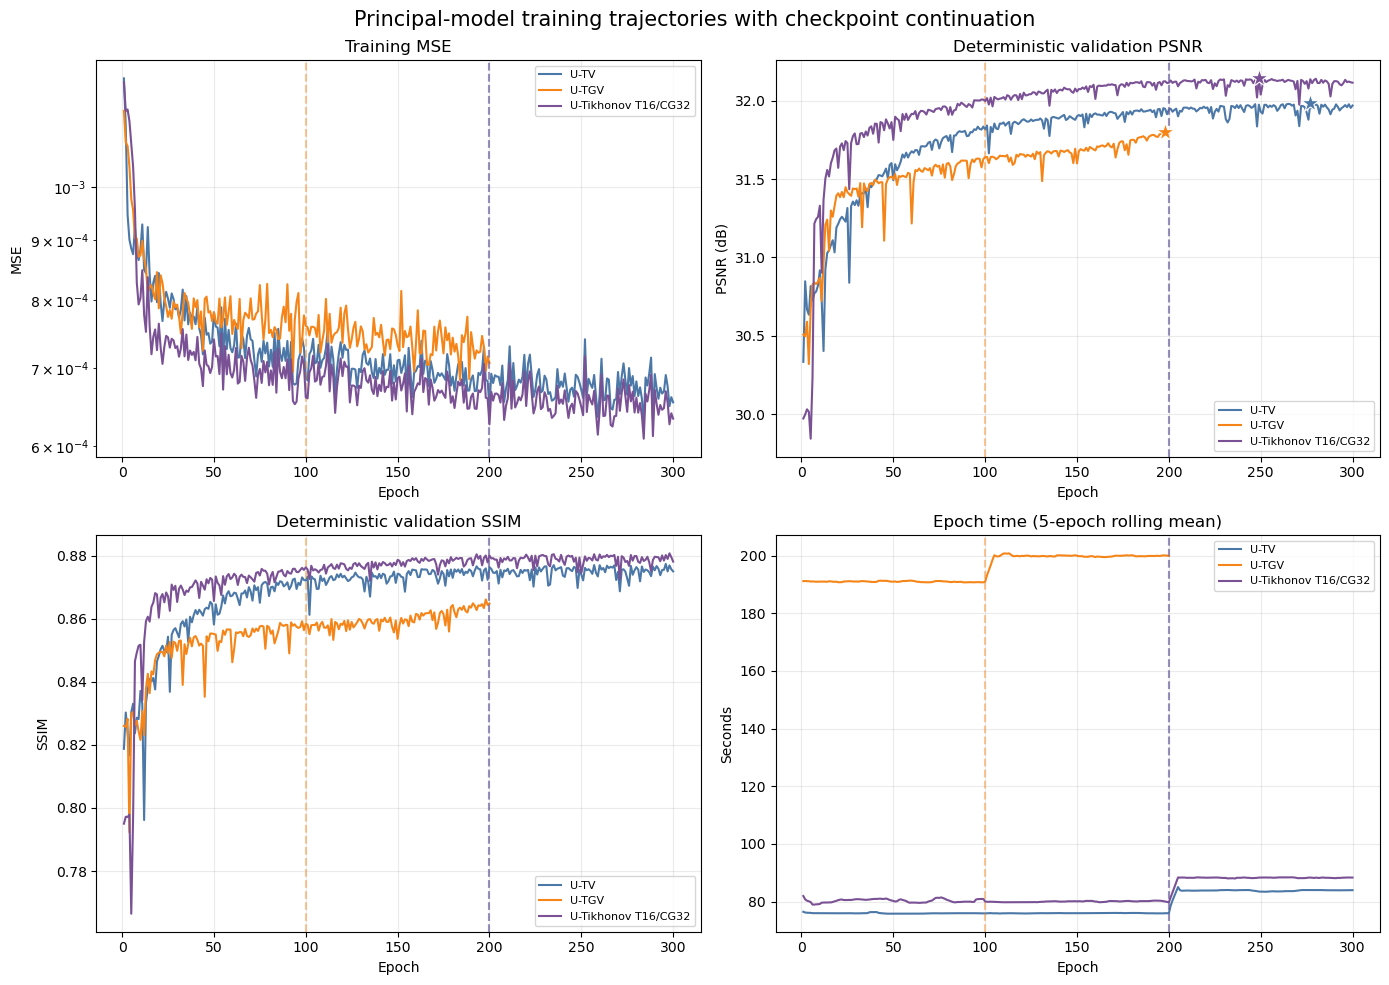

Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/training/principal_continued_training_curves.png


In [11]:
figure, axes = plt.subplots(2, 2, figsize=(14, 10))

for method, history in verified_histories.items():
    spec = SPECS[method]
    color = spec["color"]
    label = method
    axes[0, 0].plot(history["epoch"], history["train_mse"], color=color, label=label)
    axes[0, 1].plot(history["epoch"], history["val_psnr"], color=color, label=label)
    axes[1, 0].plot(history["epoch"], history["val_ssim"], color=color, label=label)
    rolling_time = history["epoch_time_sec"].rolling(5, min_periods=1).mean()
    axes[1, 1].plot(history["epoch"], rolling_time, color=color, label=label)

    best_index = history["val_psnr"].idxmax()
    axes[0, 1].scatter(
        history.loc[best_index, "epoch"],
        history.loc[best_index, "val_psnr"],
        marker="*", s=180, color=color, edgecolor="white", linewidth=0.8, zorder=5,
    )
    for axis in axes.flat:
        axis.axvline(spec["source_epoch"], color=color, linestyle="--", alpha=0.45)

axes[0, 0].set(title="Training MSE", xlabel="Epoch", ylabel="MSE")
axes[0, 0].set_yscale("log")
axes[0, 1].set(title="Deterministic validation PSNR", xlabel="Epoch", ylabel="PSNR (dB)")
axes[1, 0].set(title="Deterministic validation SSIM", xlabel="Epoch", ylabel="SSIM")
axes[1, 1].set(title="Epoch time (5-epoch rolling mean)", xlabel="Epoch", ylabel="Seconds")
for axis in axes.flat:
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)

figure.suptitle("Principal-model training trajectories with checkpoint continuation", fontsize=15)
figure.tight_layout()
curve_path = results_dir / "principal_continued_training_curves.png"
figure.savefig(curve_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(figure)
print("Saved:", curve_path)


This cell plots the continued U-Tikhonov lambda percentiles and bound proximity to show how the learned map evolves after the resume point.

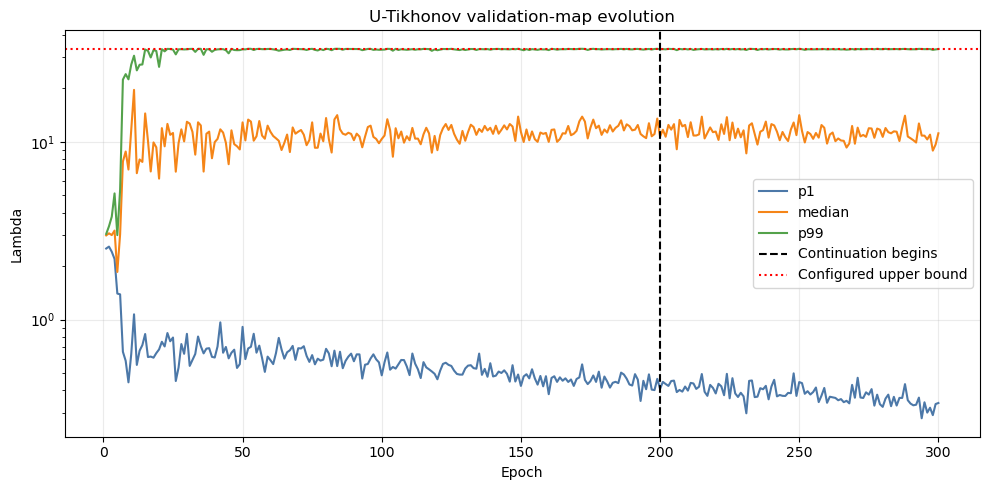

Saved: /Users/kyrillguba/Documents/Data Analytics MSc/Thesis/Python/cleaned_pipeline/results/training/u_tikhonov_continued_parameter_evolution.png


In [12]:
tikhonov_history = verified_histories.get("U-Tikhonov T16/CG32")
if tikhonov_history is not None:
    percentile_candidates = {
        "p1": ("val_lambda_p01", "val_lambda_p1"),
        "median": ("val_lambda_median",),
        "p99": ("val_lambda_p99",),
    }
    resolved_columns = {}
    for label, candidates in percentile_candidates.items():
        column = next((name for name in candidates if name in tikhonov_history), None)
        if column is not None:
            resolved_columns[label] = column

    if resolved_columns:
        figure, axis = plt.subplots(figsize=(10, 5))
        colors = {"p1": "#4C78A8", "median": "#F58518", "p99": "#54A24B"}
        for label, column in resolved_columns.items():
            axis.plot(tikhonov_history["epoch"], tikhonov_history[column], label=label, color=colors[label])
        axis.axvline(SPECS["U-Tikhonov T16/CG32"]["source_epoch"], color="black", linestyle="--", label="Continuation begins")
        checkpoint_args = source_checkpoints["U-Tikhonov T16/CG32"]["args"]
        if checkpoint_args.get("lambda_max") is not None:
            axis.axhline(float(checkpoint_args["lambda_max"]), color="red", linestyle=":", label="Configured upper bound")
        axis.set(title="U-Tikhonov validation-map evolution", xlabel="Epoch", ylabel="Lambda")
        axis.set_yscale("log")
        axis.grid(alpha=0.25)
        axis.legend()
        figure.tight_layout()
        parameter_path = results_dir / "u_tikhonov_continued_parameter_evolution.png"
        figure.savefig(parameter_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close(figure)
        print("Saved:", parameter_path)
    else:
        print("No lambda percentile columns were found in the history.")


Training was continued from the final checkpoints of the initial long runs. Both network parameters and AdamW optimiser states were restored, while the data split, noise distribution, deterministic validation set, architecture, solver depth and optimisation hyperparameters were unchanged. Because the original checkpoints did not record random-number-generator states, the continuation used a separately documented stochastic augmentation stream. Model selection was performed using the highest validation PSNR across the complete combined training history.